# LOG VS NORMAL TRAINING

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 

import scienceplots
plt.style.use(['science', 'no-latex'])
colors = ["#96A2C3","#DB96C0","#E89676","#71B6A1","#ff9287","#B1AF55","#ff8234ff","#ff9287","#5954d6","#00c6f8","#878500","#00a76c","#bdbdbd"]

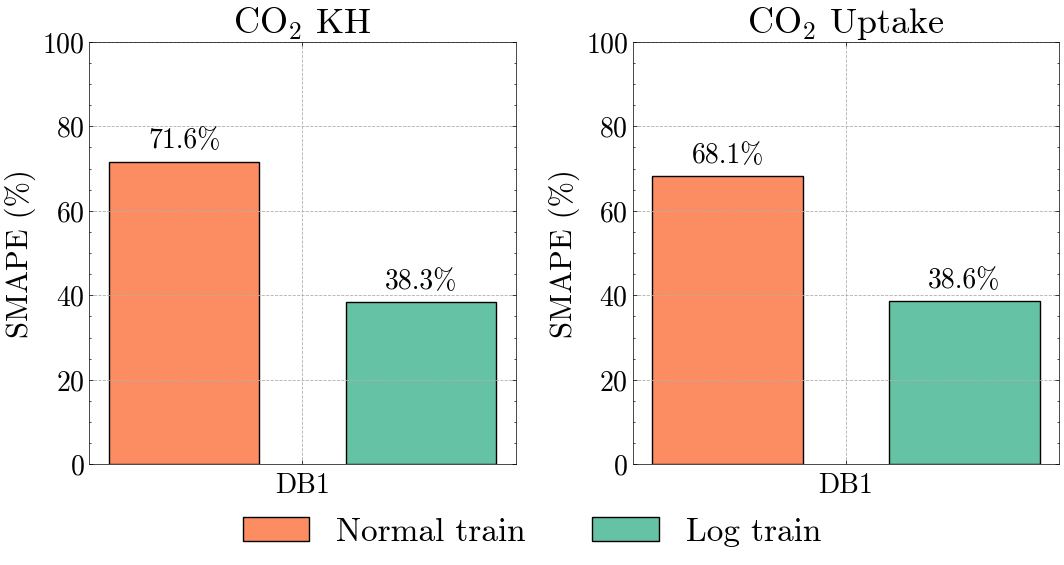

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import scienceplots

# ---------- STYLE ----------
plt.style.use(['science', 'no-latex'])
colors = sns.color_palette("Set2", 8)
plt.rcParams.update({
    "font.size": 22,
    "axes.titlesize": 26,
    "axes.labelsize": 22,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 24,
})

# Training type colors
training_type_colors = {
    "Normal train": colors[1],
    "Log train":    colors[0],
}

# ---------- RAW DATA (SMAPE %) ----------
norm_kh_co2_smape_pct = 71.59
norm_co2_uptake_smape_pct = 68.13

log_kh_co2_smape_pct = 38.31
log_co2_uptake_smape_pct = 38.61

df = pd.DataFrame({
    'features': ['Normal train', 'Log train'],
    'kh_co2': [norm_kh_co2_smape_pct, log_kh_co2_smape_pct],
    'co2_uptake': [norm_co2_uptake_smape_pct, log_co2_uptake_smape_pct],
})

# Long format (to match grouped-bar drawing loop style)
rows = []
for metric in ['kh_co2', 'co2_uptake']:
    for i, feat in enumerate(df['features']):
        rows.append({
            "metric": metric,
            "training_type": feat,
            "value": float(df.loc[i, metric]),
            "group": "DB1",  # single group label
        })
plot_df = pd.DataFrame(rows)

metric_rename = {
    "kh_co2":     r"CO$_2$ KH",
    "co2_uptake": r"CO$_2$ Uptake",
}
metric_display_order = ["kh_co2", "co2_uptake"]
groups = ["DB1"]

# ---------- BAR LAYOUT ----------
bar_width     = 0.14
bar_spacing   = 0.22
group_spacing = 0.7

def annotate_bars(ax, rects, fmt="{:.1f}", dy=None, fontsize=20):
    ymax = ax.get_ylim()[1]
    if dy is None:
        dy = 0.018 * ymax
    for r in rects:
        h = r.get_height()
        ax.text(r.get_x() + r.get_width()/2, h + dy, fmt.format(h),
                ha="center", va="bottom", fontsize=fontsize)

# ---------- DRAW ----------
fig, axs = plt.subplots(1, len(metric_display_order),
                        figsize=(5.6 * len(metric_display_order), 5.6),
                        sharey=False)

for ax, metric in zip(axs, metric_display_order):
    rects = []
    xtick_positions, xtick_labels = [], []
    current_pos = 0.0

    for group in groups:
        gdf = plot_df[(plot_df["group"] == group) & (plot_df["metric"] == metric)]

        for j, ttype in enumerate(["Normal train", "Log train"]):
            entry = gdf[gdf["training_type"] == ttype]
            if not entry.empty:
                val = float(entry["value"].values[0])
                xpos = current_pos + j * bar_spacing
                rect = ax.bar(
                    xpos, val, bar_width,
                    color=training_type_colors[ttype],
                    edgecolor="black"
                )[0]
                rects.append(rect)

        # center tick between the two bars
        xtick_positions.append(current_pos + bar_spacing / 2)
        xtick_labels.append("DB1")
        current_pos += group_spacing

    # Y limits (match your original: 0–100)
    ax.set_ylim([0, 100])
    ax.set_title(metric_rename[metric])
    ax.set_ylabel("SMAPE (%)")
    ax.set_xticks(xtick_positions)
    ax.set_xticklabels(xtick_labels)
    ax.tick_params(axis="x", pad=6)
    ax.grid(True, linestyle="--", linewidth=0.6)

    annotate_bars(ax, rects, fmt="{:.1f}%", fontsize=20)

# Legend patches
legend_patches = [
    Patch(facecolor=training_type_colors["Normal train"], label='Normal train', edgecolor="black"),
    Patch(facecolor=training_type_colors["Log train"],    label='Log train',    edgecolor="black"),
]
fig.legend(
    handles=legend_patches,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=2,
    frameon=False
)

# Optional overall title (comment out if not needed)
# fig.suptitle("DB1: Normal vs Log Training (SMAPE)", fontsize=30, y=0.98)

fig.tight_layout()
fig.savefig("db1_normal_vs_log_smape.png", dpi=300, bbox_inches="tight")
plt.show()
